In [2]:
%run 00setup.ipynb
#from src.ibkr_costs import IBKRConfig, pull_and_build_cost_table, save_cost_outputs

✅ Setup complete


In [3]:
prices = load_df("prices_clean", DATA_DIR, fmt="parquet")
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["ticker","date"]).reset_index(drop=True)
px_col = "adj_close"
prices["ret_1d"] = prices.groupby("ticker")[px_col].pct_change()

R = prices.pivot(index="date", columns="ticker", values="ret_1d").sort_index()
R = R.replace([np.inf, -np.inf], np.nan).dropna(how="all")

print("R:", R.shape, R.index.min(), R.index.max(), "| tickers:", len(R.columns))

R: (3568, 20) 2011-10-21 00:00:00 2025-12-30 00:00:00 | tickers: 20


In [4]:
W_eq = load_df("weights_eq_topk", DATA_DIR, fmt="parquet")
W_vp = load_df("weights_invvol_topk", DATA_DIR, fmt="parquet")
W_mv = load_df("weights_mv_topk", DATA_DIR, fmt="parquet")
W_cvar = load_df("weights_cvar_topk", DATA_DIR, fmt="parquet")
W_hyb = load_df("weights_hybrid_topk", DATA_DIR, fmt="parquet")

def to_weight_panel(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    return df.set_index("date").sort_index()

W_eq = to_weight_panel(W_eq)
W_vp = to_weight_panel(W_vp)
W_mv = to_weight_panel(W_mv)
W_cvar = to_weight_panel(W_cvar)
W_hyb = to_weight_panel(W_hyb)

def align_weight_columns(W, R):
    W = W.copy()
    missing = [c for c in R.columns if c not in W.columns]
    if missing:
        for c in missing:
            W[c] = 0.0
    return W.reindex(columns=R.columns, fill_value=0.0)

W_eq   = align_weight_columns(W_eq, R)
W_vp   = align_weight_columns(W_vp, R)
W_mv   = align_weight_columns(W_mv, R)
W_cvar = align_weight_columns(W_cvar, R)
W_hyb  = align_weight_columns(W_hyb, R)

print("Weights:", W_eq.shape, W_vp.shape, W_mv.shape, W_cvar.shape, W_hyb.shape)
print("Backtest input range:", R.index.min(), "to", R.index.max(), "| tickers:", len(R.columns))

Weights: (2510, 20) (2510, 20) (2510, 20) (2510, 20) (2510, 20)
Backtest input range: 2011-10-21 00:00:00 to 2025-12-30 00:00:00 | tickers: 20


In [5]:
dates = R.index

def align_and_shift(W, R):
    W = W.reindex(dates).ffill().fillna(0.0)
    s = W.sum(axis=1).replace(0, np.nan)
    W = W.div(s, axis=0).fillna(0.0)
    return W.shift(1).fillna(0.0)

W_eq_s   = align_and_shift(W_eq, R)
W_vp_s   = align_and_shift(W_vp, R)
W_mv_s   = align_and_shift(W_mv, R)
W_cvar_s = align_and_shift(W_cvar, R)
W_hyb_s  = align_and_shift(W_hyb, R)

In [6]:
def turnover(W):
    return W.diff().abs().sum(axis=1).fillna(0.0)

# transaction cost scenarios in bps per unit turnover
COST_BPS = {
    "opt": 8.0,
    "base": 12.0,
    "stress": 25.0,
}

def apply_costs(gross_ret, W, cost_bps):
    to = turnover(W)
    net = gross_ret - (cost_bps / 1e4) * to
    return net, to

In [7]:
def vol_target(net_ret, target_vol=0.12, lookback=63):
    # realized vol of strategy returns
    vol = net_ret.rolling(lookback).std() * np.sqrt(252)
    scale = (target_vol / vol).replace([np.inf, -np.inf], np.nan).clip(0, 3.0)
    # apply with 1-day lag
    scale = scale.shift(1).fillna(0.0)
    return net_ret * scale, scale


In [8]:
def run_strategy(W, cost_bps):
    gross = (W * R).sum(axis=1).fillna(0.0)
    net, to = apply_costs(gross, W, cost_bps)
    vt, scale = vol_target(net, target_vol=0.12, lookback=63)
    return pd.DataFrame({
        "gross": gross,
        "net": net,
        "vt": vt,
        "turnover": to,
        "scale": scale
    })

In [9]:
# base-case results
res_eq   = run_strategy(W_eq_s, COST_BPS["base"])
res_vp   = run_strategy(W_vp_s, COST_BPS["base"])
res_mv   = run_strategy(W_mv_s, COST_BPS["base"])
res_cvar = run_strategy(W_cvar_s, COST_BPS["base"])
res_hyb  = run_strategy(W_hyb_s, COST_BPS["base"])

# optimistic cost scenario
res_eq_opt   = run_strategy(W_eq_s, COST_BPS["opt"])
res_vp_opt   = run_strategy(W_vp_s, COST_BPS["opt"])
res_mv_opt   = run_strategy(W_mv_s, COST_BPS["opt"])
res_cvar_opt = run_strategy(W_cvar_s, COST_BPS["opt"])
res_hyb_opt  = run_strategy(W_hyb_s, COST_BPS["opt"])

# stressed cost scenario
res_eq_stress   = run_strategy(W_eq_s, COST_BPS["stress"])
res_vp_stress   = run_strategy(W_vp_s, COST_BPS["stress"])
res_mv_stress   = run_strategy(W_mv_s, COST_BPS["stress"])
res_cvar_stress = run_strategy(W_cvar_s, COST_BPS["stress"])
res_hyb_stress  = run_strategy(W_hyb_s, COST_BPS["stress"])

# Only benchmark: equal-weight universe buy-and-hold
bench_eq_univ = R.mean(axis=1).fillna(0.0)
bench_eq_univ_vt, bench_eq_univ_scale = vol_target(bench_eq_univ, target_vol=0.12, lookback=63)

In [10]:
def perf_stats(r):
    r = r.dropna()
    if len(r) < 252:
        return {}
    ann_ret = (1 + r).prod() ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = dd.min()
    return {
        "CAGR": ann_ret,
        "AnnVol": ann_vol,
        "Sharpe": sharpe,
        "MaxDD": mdd,
        "AvgTurnover": np.nan,
    }

def add_turnover(stats, turnover_series):
    if stats:
        stats["AvgTurnover"] = turnover_series.mean()
    return stats

# base-case table
rows = [
    {"name": "EQ_topk_vt", **add_turnover(perf_stats(res_eq["vt"]), res_eq["turnover"])},
    {"name": "INVVOL_topk_vt", **add_turnover(perf_stats(res_vp["vt"]), res_vp["turnover"])},
    {"name": "MV_topk_vt", **add_turnover(perf_stats(res_mv["vt"]), res_mv["turnover"])},
    {"name": "CVAR_topk_vt", **add_turnover(perf_stats(res_cvar["vt"]), res_cvar["turnover"])},
    {"name": "HYBRID_topk_vt", **add_turnover(perf_stats(res_hyb["vt"]), res_hyb["turnover"])},
    {"name": "BENCH_EQ_UNIV_vt", **perf_stats(bench_eq_univ_vt)},
]
stats = pd.DataFrame(rows).set_index("name")
display(stats)

# cost sensitivity table
cost_sensitivity_rows = [
    {"Scenario": "opt_8bps", "Portfolio": "EQ",     **add_turnover(perf_stats(res_eq_opt["vt"]), res_eq_opt["turnover"])},
    {"Scenario": "opt_8bps", "Portfolio": "INVVOL", **add_turnover(perf_stats(res_vp_opt["vt"]), res_vp_opt["turnover"])},
    {"Scenario": "opt_8bps", "Portfolio": "MV",     **add_turnover(perf_stats(res_mv_opt["vt"]), res_mv_opt["turnover"])},
    {"Scenario": "opt_8bps", "Portfolio": "CVAR",   **add_turnover(perf_stats(res_cvar_opt["vt"]), res_cvar_opt["turnover"])},
    {"Scenario": "opt_8bps", "Portfolio": "HYBRID", **add_turnover(perf_stats(res_hyb_opt["vt"]), res_hyb_opt["turnover"])},

    {"Scenario": "base_12bps", "Portfolio": "EQ",     **add_turnover(perf_stats(res_eq["vt"]), res_eq["turnover"])},
    {"Scenario": "base_12bps", "Portfolio": "INVVOL", **add_turnover(perf_stats(res_vp["vt"]), res_vp["turnover"])},
    {"Scenario": "base_12bps", "Portfolio": "MV",     **add_turnover(perf_stats(res_mv["vt"]), res_mv["turnover"])},
    {"Scenario": "base_12bps", "Portfolio": "CVAR",   **add_turnover(perf_stats(res_cvar["vt"]), res_cvar["turnover"])},
    {"Scenario": "base_12bps", "Portfolio": "HYBRID", **add_turnover(perf_stats(res_hyb["vt"]), res_hyb["turnover"])},

    {"Scenario": "stress_25bps", "Portfolio": "EQ",     **add_turnover(perf_stats(res_eq_stress["vt"]), res_eq_stress["turnover"])},
    {"Scenario": "stress_25bps", "Portfolio": "INVVOL", **add_turnover(perf_stats(res_vp_stress["vt"]), res_vp_stress["turnover"])},
    {"Scenario": "stress_25bps", "Portfolio": "MV",     **add_turnover(perf_stats(res_mv_stress["vt"]), res_mv_stress["turnover"])},
    {"Scenario": "stress_25bps", "Portfolio": "CVAR",   **add_turnover(perf_stats(res_cvar_stress["vt"]), res_cvar_stress["turnover"])},
    {"Scenario": "stress_25bps", "Portfolio": "HYBRID", **add_turnover(perf_stats(res_hyb_stress["vt"]), res_hyb_stress["turnover"])},
]

cost_sensitivity = pd.DataFrame(cost_sensitivity_rows)
display(cost_sensitivity)

,CAGR,AnnVol,Sharpe,MaxDD,AvgTurnover
name,,,,,
EQ_topk_vt,0.060676,0.109725,0.552984,-0.218808,0.085902
INVVOL_topk_vt,0.066844,0.109749,0.609060,-0.215982,0.096072
MV_topk_vt,0.049541,0.109604,0.452000,-0.220641,0.097982
CVAR_topk_vt,0.049794,0.109805,0.453478,-0.249028,0.100917
HYBRID_topk_vt,0.050233,0.109705,0.457895,-0.224606,0.097327
BENCH_EQ_UNIV_vt,0.098897,0.127530,0.775481,-0.226667,NaN


,Scenario,Portfolio,CAGR,AnnVol,Sharpe,MaxDD,AvgTurnover
0,opt_8bps,EQ,0.069316,0.109723,0.631742,-0.204016,0.085902
1,opt_8bps,INVVOL,0.077071,0.109757,0.702198,-0.201814,0.096072
2,opt_8bps,MV,0.059151,0.109591,0.539741,-0.206324,0.097982
3,opt_8bps,CVAR,0.059962,0.109805,0.546082,-0.229593,0.100917
4,opt_8bps,HYBRID,0.059848,0.109690,0.545612,-0.204357,0.097327
5,base_12bps,EQ,0.060676,0.109725,0.552984,-0.218808,0.085902
6,base_12bps,INVVOL,0.066844,0.109749,0.609060,-0.215982,0.096072
7,base_12bps,MV,0.049541,0.109604,0.452000,-0.220641,0.097982
8,base_12bps,CVAR,0.049794,0.109805,0.453478,-0.249028,0.100917
9,base_12bps,HYBRID,0.050233,0.109705,0.457895,-0.224606,0.097327


In [11]:
def common_start(*series):
    starts = []
    for s in series:
        s = s.dropna()
        nz = s.ne(0)
        starts.append(nz.idxmax() if nz.any() else s.index[0])
    return max(starts)

start = common_start(
    res_mv["vt"],
    res_eq["vt"],
    res_vp["vt"],
    res_cvar["vt"],
    res_hyb["vt"],
    bench_eq_univ_vt
)

res_mv_p   = res_mv.loc[start:, "vt"]
res_eq_p   = res_eq.loc[start:, "vt"]
res_vp_p   = res_vp.loc[start:, "vt"]
res_cvar_p = res_cvar.loc[start:, "vt"]
res_hyb_p  = res_hyb.loc[start:, "vt"]
bench_eq_p = bench_eq_univ_vt.loc[start:]

print("Plot / comparison start:", start)

Plot / comparison start: 2016-06-02 00:00:00


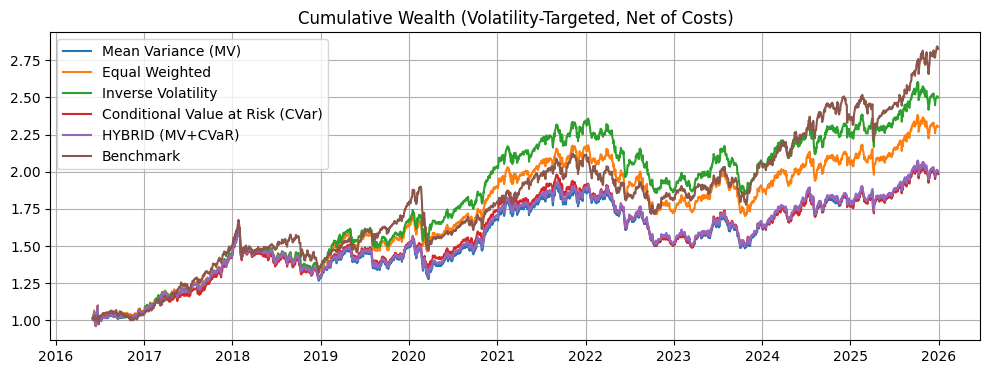

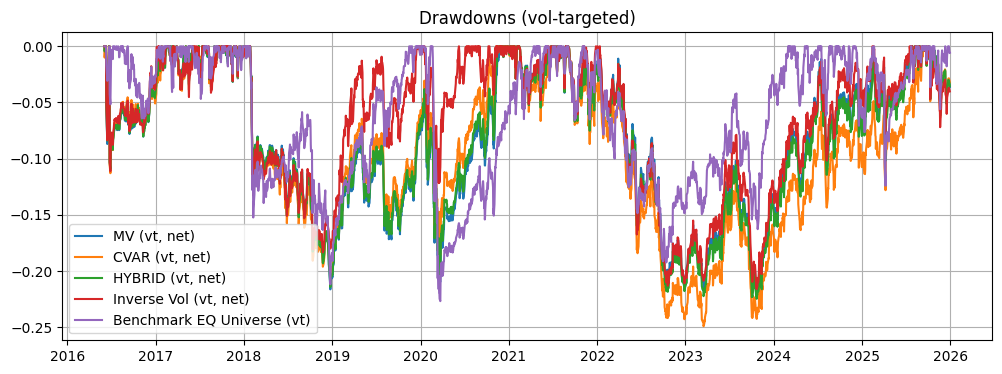

In [13]:
def plot_cum(series_dict, title):
    plt.figure(figsize=(12,4))
    for k, s in series_dict.items():
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]
        plt.plot((1 + s).cumprod().index, (1 + s).cumprod().values, label=k)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_dd(series_dict, title):
    plt.figure(figsize=(12,4))
    for k, s in series_dict.items():
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]
        cum = (1 + s).cumprod()
        dd = cum / cum.cummax() - 1
        plt.plot(dd.index, dd.values, label=k)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_cum({
    "Mean Variance (MV)": res_mv_p,
    "Equal Weighted": res_eq_p,
    "Inverse Volatility": res_vp_p,
    "Conditional Value at Risk (CVar)": res_cvar_p,
    "HYBRID (MV+CVaR)": res_hyb_p,
    "Benchmark": bench_eq_p
}, "Cumulative Wealth (Volatility-Targeted, Net of Costs)")

plot_dd({
    "MV (vt, net)": res_mv_p,
    "CVAR (vt, net)": res_cvar_p,
    "HYBRID (vt, net)": res_hyb_p,
    "Inverse Vol (vt, net)" :res_vp_p,
    "Benchmark EQ Universe (vt)": bench_eq_p
}, "Drawdowns (vol-targeted)")

In [103]:
save_df(stats.reset_index(), "bt_stats_vt", DATA_DIR, fmt="csv")

save_df(res_eq.reset_index().rename(columns={"index":"date"}), "bt_eq_topk", DATA_DIR, fmt="parquet")
save_df(res_vp.reset_index().rename(columns={"index":"date"}), "bt_invvol_topk", DATA_DIR, fmt="parquet")
save_df(res_mv.reset_index().rename(columns={"index":"date"}), "bt_mv_topk", DATA_DIR, fmt="parquet")
save_df(res_cvar.reset_index().rename(columns={"index":"date"}), "bt_cvar_topk", DATA_DIR, fmt="parquet")
save_df(res_hyb.reset_index().rename(columns={"index":"date"}), "bt_hybrid_topk", DATA_DIR, fmt="parquet")
save_df(cost_sensitivity, "bt_cost_sensitivity_vt", DATA_DIR, fmt="csv")
save_df(cost_sensitivity, "bt_cost_sensitivity_vt", DATA_DIR, fmt="parquet")
print("Saved backtest outputs.")

Saved backtest outputs.
